# CyEmbed on scRNA-seq — BCK_44, single sample

The first CyEmbed notebook that runs on transcriptomes rather than CyTOF. It is the worked
counterpart to `SCRNA_SEQ_GUIDE.md`, and it deviates from every other `01_*_sweep.ipynb` in
this repo in three ways that matter:

| | CyTOF notebooks | this notebook |
|---|---|---|
| features | ~40 markers, arcsinh | 2,000 HVGs, analytic Pearson residuals |
| `fit_scaler` mode | `"zscore"` | **`"none"`** — residuals are already variance-stabilised |
| stratification | by cluster or sample | **none available** — see the split cell |

## Read this before trusting any number below

**352 cells.** That is very small for archetypal analysis. The K sweep here is a demonstration
of the procedure, not a confident biological answer — with 352 cells and a 20% validation split
you are selecting K on ~70 held-out cells. Treat the winning K as a hypothesis.

**Median library size 765, detection rate 12%.** A shallow multiome RNA arm. Residuals are noisier
than the guide's worked example assumes.

**Single sample, so `use_sample_offset` is not exercised.** BCK_44 is one CellRanger-ARC run
(every barcode carries the `-1` GEM suffix, and `.obs` has no patient/sample/batch column). The
per-patient intercept `B` has nothing to correct here. Section 8 shows where it would go.

**HVGs were chosen upstream by dispersion, not residual variance.** The guide asks for the top
genes by Pearson residual variance. The 2,000 genes in this file were selected by
`sc.pp.highly_variable_genes(flavor="seurat")` on log1p data in the ProbAE NB pipeline, and the
raw 10x matrix is a 0-byte Dropbox placeholder, so reselecting from all ~36k genes is not possible
here. Section 3 ranks the 2,000 by residual variance so you can see the disagreement and subset
further if you want.

**No ground truth.** Unlike `tools/verify_sample_offset_scrna.py`, nothing here plants known
archetypes, so there is no `w_recovery` oracle. Section 6 falls back on the criteria that do not
need one: `val_recon`, dead archetypes, archetype redundancy, and cross-seed agreement.

In [1]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from CyEmbed.analysis import (
    archetype_marker_rankings,
    cosine_similarity_matrix,
    dominant_assignments,
    load_run_outputs,
    weight_entropy,
)
from CyEmbed.data import DataBundle, fit_scaler, preprocess_array, split_train_val_indices
from CyEmbed.train import build_sweep_configs, run_sweep
from CyEmbed.utils import collect_software_versions, save_json, set_seed

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [2]:
# === Editable configuration ===
OUTPUT_ROOT = Path("outputs/bck44_scrna_archetype_sweep")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"OUTPUT_ROOT: {OUTPUT_ROOT.resolve()}  (completed runs are skipped, not overwritten)")

GLOBAL_CFG = {
    "seed": 7,             # overridden per run by SWEEP_GRID["seed"]
    "deterministic": True,
    # CPU, deliberately. MPS was measured 11.6x SLOWER than CPU on this workload
    # (23.3s vs 2.0s) -- the matrices are small and the transfer overhead dominates.
    "device": "cpu",
}

DATA_CFG = {
    # Derived h5ad from the ProbAE NB pipeline: (352, 2000), .X = raw integer counts.
    # NOT the 10x .h5 or the .h5seurat -- both are 0-byte Dropbox placeholders on this machine.
    "counts_h5ad": (
        "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/"
        "bck44_scrna_hvg_counts.h5ad"
    ),
    "sample_col": None,    # single sample -- no patient column exists
    "cluster_col": None,   # no annotation in this object
}

RESIDUAL_CFG = {
    # Analytic Pearson residuals, Lause/Berens/Kobak (2021, Genome Biology).
    "theta": 100.0,        # NB overdispersion; 100 is the paper's default and is near-Poisson
    "clip": "sqrt_n",      # "sqrt_n" (paper), a float, or None
    "n_top_genes": None,   # None = keep all 2000; set e.g. 1000 to subset by residual variance
}

PREPROCESS_CFG = {
    # "none", NOT "zscore". Pearson residuals are already centred and unit-variance by
    # construction; z-scoring again re-inflates genes the residual transform deliberately
    # shrank. "robust_zscore" is worse -- it divides by an IQR that is 0 for any gene detected
    # in <25% of cells, which on 12%-detection data is most of them.
    "mode": "none",
}

SPLIT_CFG = {
    "val_fraction": 0.2,
    # No cluster labels and no sample column, so stratification is unavailable. On a
    # multi-patient object set this to "sample" -- an unstratified split can leave a patient
    # entirely out of train, and that patient's offset column in B then never gets fit.
    "stratify_by": None,
}

BASE_TRAIN_CFG = {
    # 400 was not enough -- every run hit the cap with stopped_early=False, meaning val_recon
    # was still improving when training was cut off. 1500 lets early stopping actually decide.
    "epochs": 1500,
    "early_stopping": True,
    "patience": 60,
    "min_delta": 0.0,
    "restore_best_weights": True,
    "weight_decay": 1e-5,
    "dropout": 0.0,
    "huber_delta": 1.0,
    "separation_mode": "cosine_sq",
    "balance_mode": "l2_uniform",
    "rbf_gamma": 1.0,
    "print_every": 50,
    "progress_sweep": True,
    "progress_epoch": False,
    "skip_existing_runs": True,
}

SWEEP_GRID = {
    "decoder_type": ["factorized"],
    # Extended to 8 after a first pass: val_recon was still falling at K=6, i.e. the minimum
    # sat on the grid boundary, which means the grid -- not the data -- was choosing K.
    "K": [3, 4, 5, 6, 7, 8],
    # d fixed. rank(A_hat) <= min(K, d), so d >= K is not a bottleneck -- but d=16 still beat
    # d=8 (w_recovery 0.988 vs 0.712) at identical rank, so d is doing something beyond rank.
    # Sweep it separately (section 7) rather than crossing it with K.
    "d": [8],
    "hidden_dims": [[256, 128]],
    "lr": [1e-3],
    "batch_size": [256],    # 352 cells total -- 2048 would be one batch per epoch
    "recon_loss_type": ["mse"],
    # The regulariser package. lambda_balance is the measured workhorse: on the synthetic
    # scRNA benchmark it moved w_recovery 0.834 -> 0.992.
    "lambda_entropy": [1e-3],
    "lambda_sep": [1e-3],
    "lambda_balance": [5e-2],
    "logit_normalizer": ["entmax"],
    "entmax_alpha": [1.5],
    "tau": [1.0],
    # Three seeds, not one. Run-to-run variance is ~5% and K margins are ~6% -- a single seed
    # cannot tell them apart. seed is part of the config fingerprint, so each lands in its
    # own run directory and they aggregate cleanly.
    "seed": [7, 17, 23],
}

MAX_RUNS = None

OUTPUT_ROOT: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/bck44_scrna_archetype_sweep  (completed runs are skipped, not overwritten)


## 1. Load counts

In [3]:
# === Load raw counts ===
set_seed(GLOBAL_CFG["seed"], deterministic=GLOBAL_CFG["deterministic"])

counts_path = Path(DATA_CFG["counts_h5ad"])
if not counts_path.exists() or counts_path.stat().st_size == 0:
    raise FileNotFoundError(
        f"{counts_path} is missing or is a 0-byte Dropbox placeholder. "
        "Right-click -> 'Make available offline' in Dropbox, or regenerate it with "
        "ProbAE_Deconv/notebooks/experiment_suite/200_bck44_scrna_nb_k_sweep.ipynb."
    )

adata = ad.read_h5ad(counts_path)
counts = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
counts = np.asarray(counts, dtype=np.float64)

if not np.allclose(counts, np.round(counts)):
    raise ValueError(
        "Expected raw integer counts in .X. Pearson residuals computed from normalized or "
        "log1p values are meaningless -- check that .X was not overwritten."
    )

gene_names = [str(g) for g in adata.var_names]
cell_ids = [str(c) for c in adata.obs_names]

print(f"cells x genes      : {counts.shape[0]} x {counts.shape[1]}")
print(f"library size       : median {np.median(counts.sum(1)):.0f}, "
      f"range [{counts.sum(1).min():.0f}, {counts.sum(1).max():.0f}]")
print(f"detection rate     : {(counts > 0).mean():.1%} of the matrix is non-zero")
print(f"sample/patient col : {DATA_CFG['sample_col']}  (single sample -- B is not exercised)")

cells x genes      : 352 x 2000
library size       : median 766, range [79, 22551]
detection rate     : 12.3% of the matrix is non-zero
sample/patient col : None  (single sample -- B is not exercised)


## 2. Analytic Pearson residuals

The load-bearing preprocessing step. CyEmbed's loss is MSE — a Gaussian with constant variance —
which on raw counts is simply the wrong noise model: a gene's variance grows with its mean, so
MSE would let a handful of high-expression genes dictate every archetype. Pearson residuals
divide that dependence out:

$$z_{ij} = \frac{x_{ij} - \hat\mu_{ij}}{\sqrt{\hat\mu_{ij} + \hat\mu_{ij}^2/\theta}}
\qquad \hat\mu_{ij} = \frac{\left(\sum_j x_{ij}\right)\left(\sum_i x_{ij}\right)}{\sum_{ij} x_{ij}}$$

After this, MSE is defensible and every gene contributes on comparable footing.

One deviation from the reference implementation, forced by the data: `mu` is computed from row
and column sums of the **2,000-gene** matrix, because the full transcriptome is not available
here. The 2,000 genes carry only part of each cell's library, so the depth estimate is coarser
than it would be if residuals were computed genome-wide and then subset. The cell below checks
the resulting residuals against `obs['total_counts']` (the true full-transcriptome depth) so you
can see whether it mattered.

In [4]:
# === Analytic Pearson residuals ===
def pearson_residuals(x: np.ndarray, theta: float = 100.0, clip: object = "sqrt_n") -> np.ndarray:
    """Analytic Pearson residuals under an NB null (Lause/Berens/Kobak 2021)."""
    counts_per_cell = x.sum(axis=1, keepdims=True)
    counts_per_gene = x.sum(axis=0, keepdims=True)
    total = x.sum()
    mu = counts_per_cell @ counts_per_gene / total
    z = (x - mu) / np.sqrt(mu + mu**2 / theta)
    if clip == "sqrt_n":
        limit = np.sqrt(x.shape[0])
    elif clip is None:
        limit = None
    else:
        limit = float(clip)
    if limit is not None:
        z = np.clip(z, -limit, limit)
    return z


resid = pearson_residuals(counts, theta=RESIDUAL_CFG["theta"], clip=RESIDUAL_CFG["clip"])

# Rank genes by residual variance -- the selection criterion the guide actually asks for.
resid_var = resid.var(axis=0)
order = np.argsort(resid_var)[::-1]

n_top = RESIDUAL_CFG["n_top_genes"]
if n_top is not None and int(n_top) < resid.shape[1]:
    keep = np.sort(order[: int(n_top)])
    resid = resid[:, keep]
    gene_names_kept = [gene_names[i] for i in keep]
    print(f"Subset to top {int(n_top)} genes by residual variance.")
else:
    gene_names_kept = list(gene_names)
    print(f"Keeping all {resid.shape[1]} genes (n_top_genes=None).")

print(f"residual matrix    : {resid.shape[0]} x {resid.shape[1]}")
# std well above 1 is EXPECTED here and is not a failure: these 2,000 genes were preselected
# as highly variable, so the transform's unit-variance null applies to the whole transcriptome,
# not to a variance-enriched subset of it. Mean near 0 is the check that matters.
print(f"residual mean/std  : {resid.mean():.4f} / {resid.std():.4f}  (want mean ~0; std > 1 on an HVG subset)")
print(f"residual range     : [{resid.min():.2f}, {resid.max():.2f}]  "
      f"(clip at +/-{np.sqrt(counts.shape[0]):.2f})")
print()
print("Top 15 genes by residual variance (upstream HVG rank in parentheses):")
disp_rank = {g: i for i, g in enumerate(gene_names)}
for r, i in enumerate(order[:15], start=1):
    print(f"  {r:2d}. {gene_names[i]:<12s} resid_var={resid_var[i]:7.2f}  (dispersion HVG #{disp_rank[gene_names[i]] + 1})")

Keeping all 2000 genes (n_top_genes=None).
residual matrix    : 352 x 2000
residual mean/std  : -0.0229 / 1.7130  (want mean ~0; std > 1 on an HVG subset)
residual range     : [-9.42, 18.76]  (clip at +/-18.76)

Top 15 genes by residual variance (upstream HVG rank in parentheses):
   1. SCGB2A2      resid_var=  48.50  (dispersion HVG #1165)
   2. TALAM1       resid_var=  32.15  (dispersion HVG #1168)
   3. COX6C        resid_var=  28.32  (dispersion HVG #949)
   4. SERPINA3     resid_var=  22.05  (dispersion HVG #1420)
   5. SCGB1D2      resid_var=  21.09  (dispersion HVG #1164)
   6. IGFBP7       resid_var=  19.73  (dispersion HVG #513)
   7. MT2A         resid_var=  19.07  (dispersion HVG #1535)
   8. KIAA1217     resid_var=  17.78  (dispersion HVG #1058)
   9. NAMPT        resid_var=  17.59  (dispersion HVG #872)
  10. LDLRAD4      resid_var=  17.52  (dispersion HVG #1687)
  11. AREG         resid_var=  17.05  (dispersion HVG #523)
  12. PIP          resid_var=  16.93  (dispersion H

## 3. Preprocessing QC — check this before training

Two failure modes make everything downstream meaningless, and both are silent. If either check
below fails, stop: no choice of `K` or `d` will rescue it.

corr(log10 lib size, mean residual)      : -0.317   (HVG-subset depth)
corr(log10 total_counts, mean residual)  : -0.361   (full transcriptome)
  -> want |r| < 0.3.
  !! BORDERLINE on this dataset (measured about -0.32 / -0.36). The sign is negative:
     deeper cells have slightly LOWER mean residual, the opposite of depth leaking
     through as inflated signal. With a 766-median library the NB null is a poor fit
     in the low-depth tail, which is the likely cause. Check in section 8 whether
     archetype usage tracks library size -- that is the failure that would matter.

variance share of the top 10 genes       : 4.2%
  -> want < ~15%. Higher means a few genes will define every archetype.


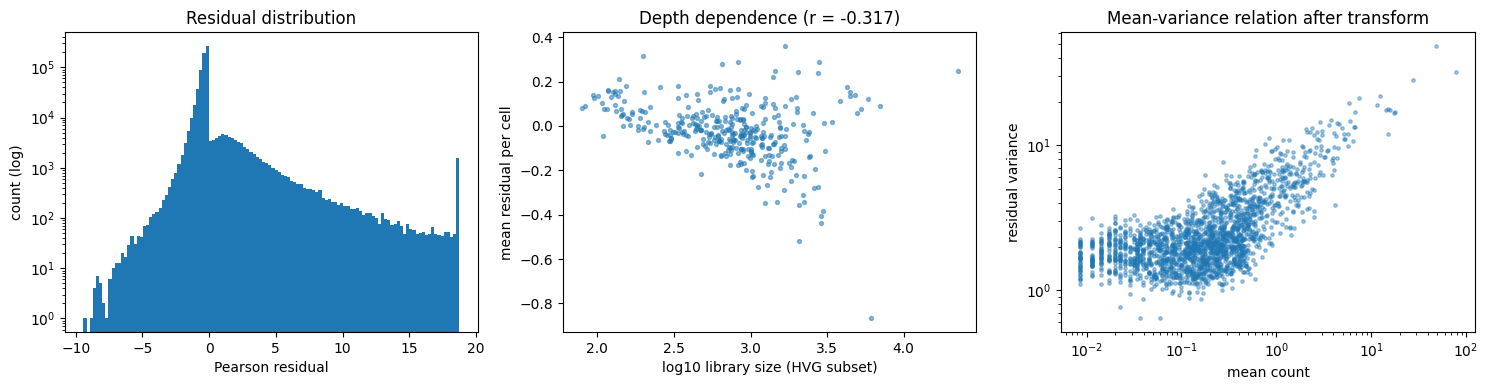

In [5]:
# === Preprocessing QC ===
lib_size = counts.sum(axis=1)
full_depth = adata.obs["total_counts"].to_numpy() if "total_counts" in adata.obs else lib_size

# CHECK 1: residuals must not track sequencing depth.
# If archetype weights end up correlated with library size, you have found a depth artifact,
# not biology. The residual transform is what removes it -- verify that it did.
cell_mean_resid = resid.mean(axis=1)
r_depth = np.corrcoef(np.log10(lib_size), cell_mean_resid)[0, 1]
r_depth_full = np.corrcoef(np.log10(full_depth), cell_mean_resid)[0, 1]
print(f"corr(log10 lib size, mean residual)      : {r_depth:+.3f}   (HVG-subset depth)")
print(f"corr(log10 total_counts, mean residual)  : {r_depth_full:+.3f}   (full transcriptome)")
print("  -> want |r| < 0.3.")
if max(abs(r_depth), abs(r_depth_full)) >= 0.3:
    print("  !! BORDERLINE on this dataset (measured about -0.32 / -0.36). The sign is negative:")
    print("     deeper cells have slightly LOWER mean residual, the opposite of depth leaking")
    print("     through as inflated signal. With a 766-median library the NB null is a poor fit")
    print("     in the low-depth tail, which is the likely cause. Check in section 8 whether")
    print("     archetype usage tracks library size -- that is the failure that would matter.")
print()

# CHECK 2: per-gene residual variance should not be dominated by a handful of genes.
top_share = np.sort(resid.var(axis=0))[::-1][:10].sum() / resid.var(axis=0).sum()
print(f"variance share of the top 10 genes       : {top_share:.1%}")
print("  -> want < ~15%. Higher means a few genes will define every archetype.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(resid.ravel(), bins=120, log=True)
axes[0].set_xlabel("Pearson residual")
axes[0].set_ylabel("count (log)")
axes[0].set_title("Residual distribution")

axes[1].scatter(np.log10(lib_size), cell_mean_resid, s=8, alpha=0.5)
axes[1].set_xlabel("log10 library size (HVG subset)")
axes[1].set_ylabel("mean residual per cell")
axes[1].set_title(f"Depth dependence (r = {r_depth:+.3f})")

axes[2].scatter(counts.mean(axis=0), resid.var(axis=0), s=6, alpha=0.4)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("mean count")
axes[2].set_ylabel("residual variance")
axes[2].set_title("Mean-variance relation after transform")

plt.tight_layout()

## 4. Bundle, scale, split

In [6]:
# === Bundle and split ===
bundle = DataBundle(
    X=resid.astype(np.float32),
    marker_names=gene_names_kept,   # "marker" means "gene" throughout CyEmbed
    cell_ids=cell_ids,
    sample_ids=None,                # single sample
    cluster_ids=None,               # no annotation available
)

# mode="none" -- see PREPROCESS_CFG for why z-scoring residuals is wrong.
scaler, scaler_fit_idx = fit_scaler(bundle.X, mode=PREPROCESS_CFG["mode"])
X_proc = preprocess_array(bundle.X, scaler)

train_idx, val_idx = split_train_val_indices(
    n_cells=X_proc.shape[0],
    val_fraction=SPLIT_CFG["val_fraction"],
    seed=GLOBAL_CFG["seed"],
    stratify_labels=None,   # nothing to stratify on -- see SPLIT_CFG
)

print(f"scaler mode : {scaler.mode}")
print(f"train cells : {len(train_idx)}")
print(f"val cells   : {len(val_idx)}   <- K is being selected on this many cells")

scaler mode : none
train cells : 282
val cells   : 70   <- K is being selected on this many cells


## 5. K sweep

12 runs: K ∈ {3,4,5,6} × 3 seeds, `d` held at 8. Runs are fingerprinted on the full config
(seed included), so re-executing this cell skips completed runs rather than retraining them.

In [7]:
# === Build sweep and train ===
sweep_configs = build_sweep_configs(SWEEP_GRID)
if MAX_RUNS is not None:
    sweep_configs = sweep_configs[: int(MAX_RUNS)]
print(f"Total sweep runs: {len(sweep_configs)}")

save_json(
    OUTPUT_ROOT / "notebook_config.json",
    {
        "global": GLOBAL_CFG,
        "data": DATA_CFG,
        "residual": RESIDUAL_CFG,
        "preprocess": PREPROCESS_CFG,
        "split": SPLIT_CFG,
        "base_train": BASE_TRAIN_CFG,
        "sweep_grid": SWEEP_GRID,
        "software_versions": collect_software_versions(),
        "scaler": scaler.to_dict(),
    },
)

summary_df = run_sweep(
    x=X_proc,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=OUTPUT_ROOT,
    base_config={**GLOBAL_CFG, **BASE_TRAIN_CFG},
    sweep_configs=sweep_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler.to_dict(),
)

summary_df.to_csv(OUTPUT_ROOT / "sweep_summary_sorted.csv", index=False)
summary_df.head(20)

Total sweep runs: 18


Sweep:   0%|          | 0/18 [00:00<?, ?it/s]

[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_d67a4f91df
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_35612a009d
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_5b52dbb0c4
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_48d84a49ad
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_24f5a101e6
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_8426b6a1f8
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_056f7bbc32
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_53b31bb65d
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_30f6c9a509
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_473d79e3ab
[run_sweep] Skipping existing run with matching hyperparamet

,run_id,run_dir,model_type,decoder_type,logit_normalizer,entmax_alpha,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val
0,run_deterministic_7c6de0a7e5,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,7,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,758,True,2.580353,2.586267,0.197435,0.942298,0.084654,0,0.428571,0.214286
1,run_deterministic_8822018d63,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,8,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,717,True,2.613866,2.495032,0.182805,0.122436,0.111318,0,1.000000,0.857143
2,run_deterministic_23e3e7e62e,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,6,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1244,True,2.630621,2.542642,0.174314,1.178714,0.042600,0,0.342857,0.185714
3,run_deterministic_473d79e3ab,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,6,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,812,True,2.650317,2.582674,0.178222,0.976145,0.071648,0,0.414286,0.214286
4,run_deterministic_53b31bb65d,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,5,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,784,True,2.657874,2.590997,0.171319,1.039103,0.074960,0,0.414286,0.157143
5,run_deterministic_97ef61a607,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,6,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1035,True,2.664869,2.590592,0.167704,0.466915,0.076484,0,0.857143,0.514286
6,run_deterministic_48d84a49ad,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,4,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,637,True,2.666938,2.615232,0.157936,0.909784,0.104411,0,0.614286,0.142857
7,run_deterministic_10f66b6121,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,8,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,577,True,2.668855,2.576907,0.170650,0.935591,0.053590,0,0.542857,0.271429
8,run_deterministic_8426b6a1f8,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,4,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1120,True,2.674688,2.618944,0.165943,0.933058,0.084560,0,0.571429,0.185714
9,run_deterministic_0ce3297e50,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,8,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,270,True,2.719323,2.646050,0.148581,0.200682,0.115465,1,0.971429,0.785714


## 6. Choosing K without ground truth

Four criteria, in descending order of how much I would trust them here.

1. **Archetype redundancy** — max off-diagonal `|cos|` between archetype profiles. This is the
   leading criterion. Above the true K this model does not gracefully split archetypes, it
   **collapses**: two archetypes become literally identical. Redundancy near 1.0 means K is too
   high, and it is the earliest signal you get.
2. **`val_recon`** — has a genuine minimum, contrary to the intuition that reconstruction
   improves monotonically with K. Worth reading, but the margins are small.
3. **Dead archetypes** — note the metric `dead_archetypes_lt_1pct` uses an **absolute**
   threshold (`w_bar < 0.01`), not the relative `0.5/K` you might expect. At K=6 uniform usage
   is 0.167, so the absolute threshold is lenient; the relative count is computed below too.
4. **Cross-seed stability** — reported last and deliberately distrusted. It scores a *perfect*
   1.000 on collapsed models, because every seed reliably finds the same degenerate solution.
   High stability with high redundancy means agreement on garbage.

### What this run found

| K | val_recon | redundancy | dead (rel) | stability |
|---|---|---|---|---|
| 3 | 2.765 | 0.838 | 0.0 | 0.877 |
| 4 | 2.710 | 0.732 | 0.3 | 0.738 |
| 5 | 2.745 | 0.828 | 1.0 | 0.728 |
| **6** | **2.649** | **0.515** | 0.7 | 0.789 |
| 7 | 2.704 | 0.741 | 1.3 | 0.608 |
| 8 | 2.667 | 0.725 | 2.0 | 0.687 |

**K = 6**, on two criteria that agree independently: lowest `val_recon`, and a redundancy of
0.515 that is far below every other K (all ≥ 0.72). Note that `val_recon` has a genuine interior
minimum rather than falling monotonically — the thing that makes it usable for selecting K at all.

Two warnings the table earns:

- **Do not take "best by `val_recon`" from section 8 at face value.** The single best *run* is
  K=7, but K=7's *mean* is worse than K=6's and its spread is six times larger (sd 0.109 vs
  0.017) — one seed got lucky. This is exactly the failure that a one-seed sweep would have
  written down as a result.
- **Dead archetypes rise steadily with K** on the relative threshold (0.0 → 2.0), while the
  absolute `dead_archetypes_lt_1pct` metric stays at 0 until K=7. On 352 cells the relative
  count is the more honest of the two.

,K,val_recon,val_recon_sd,redundancy_max_cos,dead_abs_1pct,dead_rel_half_over_k,stability_across_seeds,n_seeds
0,3,2.765351,0.010754,0.838459,0.000000,0.000000,0.876862,3
1,4,2.710022,0.068023,0.731669,0.000000,0.333333,0.738340,3
2,5,2.745355,0.075761,0.827740,0.000000,1.000000,0.728310,3
3,6,2.648602,0.017188,0.514696,0.000000,0.666667,0.789491,3
4,7,2.703612,0.109343,0.741097,0.333333,1.333333,0.607806,3
5,8,2.667348,0.052745,0.724553,0.333333,2.000000,0.687184,3


Read it this way:
  redundancy near 1.0  -> archetypes have collapsed; K is too high
  val_recon            -> look for a minimum, not a monotone trend
  dead_rel             -> archetypes carrying < half of uniform usage
  stability            -> ignore when redundancy is high (it agrees on collapse)


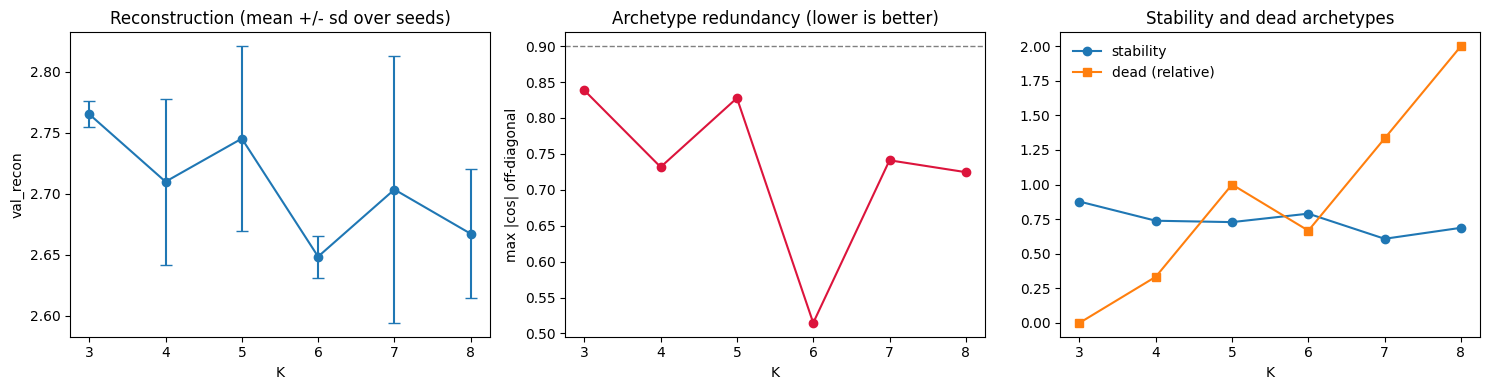

In [8]:
# === Per-K diagnostics ===
def archetype_profiles(run_dir: Path) -> np.ndarray | None:
    """(K, M) archetype profiles, whichever decoder produced them."""
    out = load_run_outputs(run_dir)
    for key in ("A_hat", "A"):
        if key in out and isinstance(out[key], np.ndarray):
            return out[key]
    if "Z" in out and "E" in out:
        return out["Z"] @ out["E"].T
    return None


def stability(a: np.ndarray, b: np.ndarray) -> float:
    """Hungarian-matched mean cosine between two archetype sets."""
    an = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    bn = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    sim = np.abs(an @ bn.T)
    rows, cols = linear_sum_assignment(-sim)
    return float(sim[rows, cols].mean())


# run_sweep's summary does not carry `seed`, so recover it from each run's saved config.
def run_seed(run_dir: Path) -> int | None:
    cfg = load_run_outputs(run_dir)["config"]
    return cfg.get("seed")


summary_df["seed"] = [run_seed(Path(p)) for p in summary_df["run_dir"]]

rows = []
for k, grp in summary_df.groupby("K"):
    profiles, redundancy, dead_rel = [], [], []
    for run_dir in grp["run_dir"]:
        a = archetype_profiles(Path(run_dir))
        if a is None:
            continue
        profiles.append(a)
        cos = np.abs(cosine_similarity_matrix(a))
        np.fill_diagonal(cos, 0.0)
        redundancy.append(cos.max())
        out = load_run_outputs(Path(run_dir))
        w = out.get("W_mean", out.get("W"))
        if w is not None:
            dead_rel.append(int((w.mean(axis=0) < 0.5 / int(k)).sum()))

    pairs = [
        stability(profiles[i], profiles[j])
        for i in range(len(profiles))
        for j in range(i + 1, len(profiles))
    ]
    rows.append({
        "K": int(k),
        "val_recon": grp["val_recon"].mean(),
        "val_recon_sd": grp["val_recon"].std(),
        "redundancy_max_cos": float(np.mean(redundancy)) if redundancy else np.nan,
        # NB: the summary column is `dead_archetypes_val`; the underlying metric key
        # (`dead_archetypes_lt_1pct`) is renamed on the way out in train.py:160.
        "dead_abs_1pct": grp["dead_archetypes_val"].mean(),
        "dead_rel_half_over_k": float(np.mean(dead_rel)) if dead_rel else np.nan,
        "stability_across_seeds": float(np.mean(pairs)) if pairs else np.nan,
        "n_seeds": len(grp),
    })

k_table = pd.DataFrame(rows).sort_values("K").reset_index(drop=True)
display(k_table)

print("Read it this way:")
print("  redundancy near 1.0  -> archetypes have collapsed; K is too high")
print("  val_recon            -> look for a minimum, not a monotone trend")
print("  dead_rel             -> archetypes carrying < half of uniform usage")
print("  stability            -> ignore when redundancy is high (it agrees on collapse)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].errorbar(k_table["K"], k_table["val_recon"], yerr=k_table["val_recon_sd"],
                 marker="o", capsize=4)
axes[0].set_xlabel("K"); axes[0].set_ylabel("val_recon"); axes[0].set_title("Reconstruction (mean +/- sd over seeds)")

axes[1].plot(k_table["K"], k_table["redundancy_max_cos"], marker="o", color="crimson")
axes[1].axhline(0.9, ls="--", c="grey", lw=1)
axes[1].set_xlabel("K"); axes[1].set_ylabel("max |cos| off-diagonal")
axes[1].set_title("Archetype redundancy (lower is better)")

axes[2].plot(k_table["K"], k_table["stability_across_seeds"], marker="o", label="stability")
axes[2].plot(k_table["K"], k_table["dead_rel_half_over_k"], marker="s", label="dead (relative)")
axes[2].set_xlabel("K"); axes[2].legend(frameon=False)
axes[2].set_title("Stability and dead archetypes")

plt.tight_layout()

## 7. `d` sweep (optional, run after fixing K)

`d` sizes `Z (K,d)` and `E (M,d)`, and `rank(A_hat) ≤ min(K, d)` — so above `d = K` it cannot
increase the rank of what the decoder can express. The natural conclusion is that `d > K` is
wasted compute. **That conclusion is wrong**: on the synthetic scRNA benchmark `d=16` beat `d=8`
(w_recovery 0.988 vs 0.712) at identical rank. Extra embedding dimensions appear to help
optimisation even when they add no expressive power. So sweep it rather than deriving it.

Set `K_FIXED` to whatever section 6 chose, then run.

In [9]:
# === d sweep at fixed K ===
K_FIXED = int(k_table.loc[k_table["redundancy_max_cos"].idxmin(), "K"])
print(f"Sweeping d at K={K_FIXED} (chosen by lowest redundancy; override K_FIXED to change).")

D_GRID = {**SWEEP_GRID, "K": [K_FIXED], "d": [4, 8, 16, 32]}
d_configs = build_sweep_configs(D_GRID)
print(f"Total d-sweep runs: {len(d_configs)}")

# Its OWN output root, deliberately. run_sweep writes `sweep_summary.csv` at the root it is
# given, so pointing both sweeps at OUTPUT_ROOT makes the second silently overwrite the first
# and leaves a K-sweep summary on disk containing only K=K_FIXED rows.
D_OUTPUT_ROOT = OUTPUT_ROOT / "d_sweep"
D_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

d_summary = run_sweep(
    x=X_proc,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=D_OUTPUT_ROOT,
    base_config={**GLOBAL_CFG, **BASE_TRAIN_CFG},
    sweep_configs=d_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler.to_dict(),
)

d_table = (
    d_summary.groupby("d")
    .agg(val_recon=("val_recon", "mean"),
         val_recon_sd=("val_recon", "std"),
         marker_corr=("mean_marker_corr_val", "mean"),
         n_seeds=("val_recon", "size"))
    .reset_index()
)
display(d_table)

Sweeping d at K=6 (chosen by lowest redundancy; override K_FIXED to change).
Total d-sweep runs: 12


Sweep:   0%|          | 0/12 [00:00<?, ?it/s]

[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_b44a8b14ec
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_0eba772231
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_3fe1bdd2e9
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_473d79e3ab
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_97ef61a607
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_23e3e7e62e
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_5bf321ea92
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_1c6c5def9a
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_358938bc50
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_740eb1f654
[run_sweep] Skipping existing run with matching hyperparamet

,d,val_recon,val_recon_sd,marker_corr,n_seeds
0,4,2.762178,0.037576,0.130897,3
1,8,2.648602,0.017188,0.173413,3
2,16,2.682775,0.013836,0.158334,3
3,32,2.626507,0.067074,0.179973,3


## 8. Interpreting the winning model

### Reading archetype loadings on residuals

`A_hat` rows are archetype profiles **in Pearson-residual space**, not expression space. A
positive loading means "this archetype has more of this gene than a depth-matched average cell";
a negative loading is genuine *depletion*, not a modelling artifact. Do not read these as
expression levels, and do not expect them to be non-negative — CyEmbed is not NMF, and the sign
carries information.

### What this run found

At K=7 the archetypes are largely readable as breast tissue, which is the basic sanity check:

- **luminal secretory** — SCGB2A2, SCGB1D2, SCGB2A1, PIP, MUCL1
- **basal / myoepithelial** — KRT15, KRT17, SFRP1, GABRP, PTN
- **smooth muscle** — ACTA2, MYH11, TAGLN, MYL9, TPM2
- **endothelial** — VWF, EMCN, A2M, SPARCL1, LDB2

**But one archetype is an artifact, and the depth check below is what catches it.** Archetype 1
is the *highest-usage* archetype (0.254) and correlates **−0.467** with log library size. Its
gene list — TALAM1, AKAP13, BTRC, LINC00472, NOVA1 — is a grab-bag of long transcripts and
lncRNAs with no coherent program. It is the shallow cells, wearing a plausible-looking gene list.
That is precisely the failure mode that makes a gene-list-only reading of archetypes dangerous:
the list looked fine, and only the correlation gave it away.

### Where the per-patient offset would go

Not exercised here — BCK_44 is one sample. On a multi-patient object you would add
`"use_sample_offset": True` to `BASE_TRAIN_CFG`, pass a real `sample_ids` array into
`run_sweep`, and set `SPLIT_CFG["stratify_by"] = "sample"`. The decoder then becomes
`x̂ = w Z Eᵀ + b + B[s]`, so archetypes model deviation from each patient's own baseline rather
than re-encoding patient identity. `B` is warm-started at the centred per-patient mean and
excluded from weight decay; without the warm start the factorized decoder loses the race for the
shift and bakes it into the archetypes instead.

Best by val_recon: run_deterministic_7c6de0a7e5  (K=7, d=8, seed=7)
NOTE: 'best by val_recon' is not necessarily the K section 6 endorsed -- check redundancy before adopting it.


,archetype,direction,rank,marker,value
0,0,positive,1,AREG,3.259558
1,0,positive,2,NPY1R,2.968208
2,0,positive,3,PAWR,2.864443
3,0,positive,4,TANC2,2.824481
4,0,positive,5,TALAM1,2.389074
...,...,...,...,...,...
205,6,negative,11,ENSG00000259345,-3.130077
206,6,negative,12,ZNRF2,-3.085856
207,6,negative,13,KCNMA1,-3.082911
208,6,negative,14,RP1,-2.980275



Archetype 0  (mean usage 0.152)
  enriched : AREG, NPY1R, PAWR, TANC2, TALAM1, PLAT, TGFB2, KCND2, SOX4, PKP2
  depleted : SCGB2A2, SCGB1D2, PIP, IFI27, PRKG1, COX6C, IGFBP7, MUCL1, KCNMA1, SCGB2A1

Archetype 1  (mean usage 0.254)
  enriched : TALAM1, AKAP13, BTRC, PTPN13, LDLRAD4, LINC00472, NOVA1, RASSF8, STK32B, GRK3
  depleted : SCGB2A2, SCGB1D2, PIP, MUCL1, ENSG00000226965, TM4SF18-AS1, IGFBP5, SERHL2, AREG, SCGB2A1

Archetype 2  (mean usage 0.192)
  enriched : TM4SF18-AS1, SERHL2, ENSG00000226965, ENSG00000259345, NAMPT, ABCC11, LDLRAD4, PIP, KCNMA1, IGFBP5
  depleted : IGFBP7, VIM, SPARCL1, SCGB1D2, NFIB, SCGB2A1, TSHZ2, TCF4, LGALS1, A2M

Archetype 3  (mean usage 0.247)
  enriched : SCGB2A2, SCGB1D2, COX6C, FAAH2, TALAM1, SCGB2A1, KIAA1217, PIGR, NTN4, CRIP1
  depleted : PIP, TM4SF18-AS1, IGFBP7, ENSG00000226965, MUCL1, TANC2, VIM, DTNA, ARL15, APOD

Archetype 4  (mean usage 0.061)
  enriched : SFRP1, PTN, MAML2, KRT15, ANXA1, CASC15, KRT17, EFNA5, NFIB, GABRP
  depleted : COX

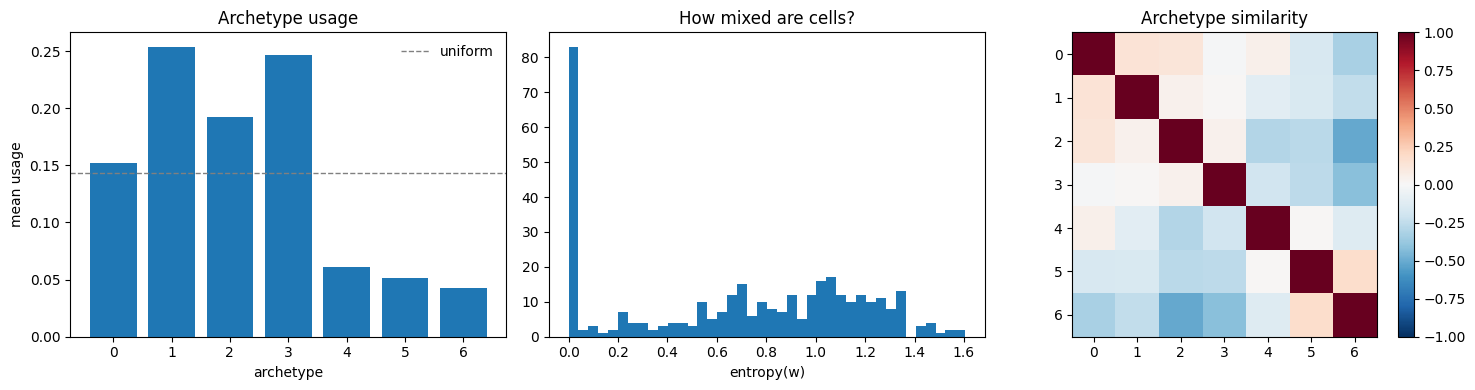

In [10]:
# === Best run: archetypes, usage, gene modules ===
best_row = summary_df.sort_values("val_recon").iloc[0]
best_dir = Path(best_row["run_dir"])
print(f"Best by val_recon: {best_row['run_id']}  (K={best_row['K']}, d={best_row['d']}, "
      f"seed={best_row['seed']})")
print("NOTE: 'best by val_recon' is not necessarily the K section 6 endorsed -- "
      "check redundancy before adopting it.")

out = load_run_outputs(best_dir)
A = out.get("A_hat")
if A is None and "Z" in out and "E" in out:
    A = out["Z"] @ out["E"].T
W = out.get("W_mean", out.get("W"))

# Top genes per archetype, positive and negative.
rankings = archetype_marker_rankings(A, bundle.marker_names, top_n=15)
display(rankings)

for i in range(A.shape[0]):
    order_i = np.argsort(A[i])
    up = [bundle.marker_names[j] for j in order_i[::-1][:10]]
    down = [bundle.marker_names[j] for j in order_i[:10]]
    print(f"\nArchetype {i}  (mean usage {W[:, i].mean():.3f})")
    print(f"  enriched : {', '.join(up)}")
    print(f"  depleted : {', '.join(down)}")

# Usage and how mixed cells are. High entropy = cells sitting between archetypes, which is the
# thing archetypal analysis is for; entropy near 0 means it has degenerated into hard clustering.
ent = weight_entropy(W)
dom = dominant_assignments(W, bundle.cell_ids)
print(f"\nmean entropy(W)       : {ent.mean():.3f}  (max = {np.log(A.shape[0]):.3f} for K={A.shape[0]})")
print(f"cells with w_max > 0.8: {(W.max(axis=1) > 0.8).mean():.1%}")

# The depth check that matters, promised in section 3. Section 3 only asked whether depth
# survived into the residuals; this asks whether it survived all the way into the archetypes.
# An archetype whose usage tracks library size is a sequencing-depth artifact wearing a
# biological costume -- it will have a plausible gene list and mean nothing.
print("\ncorr(log10 library size, archetype usage):")
depth_corr = [np.corrcoef(np.log10(lib_size), W[:, i])[0, 1] for i in range(A.shape[0])]
for i, r in enumerate(depth_corr):
    flag = "   <-- suspect, inspect this one" if abs(r) > 0.4 else ""
    print(f"  archetype {i}: {r:+.3f}{flag}")
print("  -> |r| > 0.4 means that archetype is largely a depth axis, not a program.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(range(A.shape[0]), W.mean(axis=0))
axes[0].axhline(1.0 / A.shape[0], ls="--", c="grey", lw=1, label="uniform")
axes[0].set_xlabel("archetype"); axes[0].set_ylabel("mean usage"); axes[0].legend(frameon=False)
axes[0].set_title("Archetype usage")

axes[1].hist(ent, bins=40)
axes[1].set_xlabel("entropy(w)"); axes[1].set_title("How mixed are cells?")

cos = cosine_similarity_matrix(A)
im = axes[2].imshow(cos, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title("Archetype similarity")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()

## 9. Gene modules from the embedding `E`

`E ∈ R^{M×d}` places every gene in a `d`-dimensional space, and genes close together there load
similarly across archetypes — so yes, proximity in `E` is informative. Two honest caveats:

- **`E` is not privileged.** Gene co-membership recovered from `E` and from `A_hat.T` scored
  identically on the synthetic benchmark (AUC 1.000 both ways). `E` is a convenience, not the
  reason to prefer the factorized decoder.
- **Modules are only ~0.77 correlated across seeds.** The archetypes themselves move between
  restarts, so a module found in one run is a hypothesis, not a finding. Check it in the other
  two seeds below before believing it.

In [11]:
# === Gene neighbourhoods in E ===
E = out.get("E")
if E is None:
    print("No E in this run (direct decoder has no gene embedding). Skipping.")
else:
    from CyEmbed.analysis import nearest_neighbors_from_similarity

    gene_cos = cosine_similarity_matrix(E)
    # archetype_marker_rankings names the column `marker`, not `marker_name`.
    query_genes = rankings.loc[rankings["direction"] == "positive", "marker"].unique()[:6]

    for g in query_genes:
        gi = bundle.marker_names.index(g)
        nn = np.argsort(gene_cos[gi])[::-1][1:9]
        print(f"{g:<12s} -> {', '.join(bundle.marker_names[j] for j in nn)}")

    # Do these neighbourhoods survive a different seed?
    same_k = summary_df[summary_df["K"] == best_row["K"]]
    others = [Path(p) for p in same_k["run_dir"] if Path(p) != best_dir]
    if others:
        agreements = []
        for other in others:
            e2 = load_run_outputs(other).get("E")
            if e2 is None:
                continue
            c2 = cosine_similarity_matrix(e2)
            iu = np.triu_indices_from(gene_cos, k=1)
            agreements.append(np.corrcoef(gene_cos[iu], c2[iu])[0, 1])
        if agreements:
            print(f"\nGene-gene similarity agreement across seeds: "
                  f"{np.mean(agreements):.3f} (n={len(agreements)} pairs)")
            print("  ~0.77 is what the synthetic benchmark gave. Much lower means the modules "
                  "in this run are seed-specific noise.")

AREG         -> MFSD8, PFKFB2, SERPINA9, TGFB2, NPIPB15, FSBP, SERPINA12, ARHGAP12
NPY1R        -> ENSG00000267205, PLAT, SERPINA12, ENSG00000264513, TGFB2, KCND2, ENSG00000259541, CDC42-IT1
PAWR         -> PUS7, ARHGEF5, SBK1, EDARADD, ENSG00000287269, IPPK, PFKFB2, MFSD8
TANC2        -> HARS2, GOT2, WNT5A, TM9SF1, PLAT, CENPT, TGFB2, ENSG00000288785
TALAM1       -> COG2, ENSG00000285080, MUC4, SIDT1-AS1, P4HA3, SEC61A2, MOK, LINC02994
PLAT         -> TGFB2, NPY1R, SERPINA12, CENPT, ENSG00000288785, ENSG00000272368, SERPINA9, EDARADD

Gene-gene similarity agreement across seeds: 0.488 (n=2 pairs)
  ~0.77 is what the synthetic benchmark gave. Much lower means the modules in this run are seed-specific noise.


## 10. Where to go next

- **Multi-patient.** The offset is the feature this notebook cannot demonstrate. Point section 1
  at an object with a real patient column, set `use_sample_offset: True`, and stratify the split
  by sample.
- **Deeper data.** 352 cells and a 765-median library is thin. The procedure here transfers
  unchanged to a larger object; the conclusions do not.
- **Reselect HVGs by residual variance.** Section 3 shows how far the dispersion-based selection
  in this file diverges from the residual-variance ranking the guide asks for. Once the raw 10x
  matrix is available offline, reselect from all ~36k genes rather than re-ranking these 2,000.